# Step 4 Synthetic Experiments / Step 4 合成数据实验

This notebook runs the Step 4 synthetic experiments, saves artifacts, and checks whether the current run meets the Step 4 targets.
本 notebook 用于运行 Step 4 合成数据实验、保存结果，并检查当前运行是否达到 Step 4 目标。

**Latest Verified Status / 最新验证状态**
- The latest formal_target run passes all three Step 4 acceptance checks. / 当前 latest formal_target 结果已通过三项 Step 4 验收指标。
- E1c uses a local temperature override of 0.5 only for the nonlinear run. / E1c 仅在非线性场景局部使用 temperature=0.5。
- E1b proxy_recon_r2 now reflects the post-selection closed-form refit of the linear proxy head on frozen z_i. / E1b 的 proxy_recon_r2 当前反映的是在冻结 z_i 上、best checkpoint 选出后对线性重构头做闭式重拟合的结果。

**Workflow / 流程**
1. Configure paths, imports, and plotting defaults. / 配置路径、导入依赖并设置绘图风格。
2. Select a training preset and build experiment arguments. / 选择训练预设并生成实验参数。
3. Run E1a, E1b, and optionally E1c. / 运行 E1a、E1b，并按需运行 E1c。
4. Load summaries, compare against thresholds, and inspect figures. / 读取汇总结果、对照阈值，并检查图表。
5. Use the retrospective diagnostics below to confirm why the earlier failures occurred and why the current fixes work. / 使用后续回顾性诊断确认早期失败的根因，以及当前修复为何有效。

**Training Presets / 训练预设**

| Plan | Epochs | Patience | Log Every | Usage |
| --- | ---: | ---: | ---: | --- |
| quick_check | 3 | 1 | 1 | Fast smoke test / 快速冒烟验证 |
| notebook_medium | 30 | 8 | 5 | Standard notebook run / notebook 标准实验 |
| formal_target | 200 | 20 | 10 | Formal target run / 正式实验配置 |

**Pass Criteria / 达标标准**

| Experiment | Metrics | Threshold |
| --- | --- | --- |
| E1a linear | kstar_mae, kstar_spearman_rho | kstar_mae < 1.0 and kstar_spearman_rho > 0.8 |
| E1b identification | proxy_recon_r2, z_spearman_rho | proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8 |
| E1c nonlinear | kstar_mae, kstar_spearman_rho | kstar_mae < 1.0 and kstar_spearman_rho > 0.8 |

The default active plan below is formal_target. Switch back to notebook_medium only when you need a faster interactive run.
下面默认激活的是 formal_target；只有在你需要更快的交互式运行时，再切回 notebook_medium。

In [16]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"repo_root = {repo_root}")


repo_root = C:\DevSpace\PyDevspace\CMDL


In [17]:
from argparse import Namespace
import importlib

import numpy as np

from experiments import run_synthetic as run_synthetic_module
from visualization.kstar_distribution import plot_kstar_scatter
from visualization.omega_heatmap import plot_omega_heatmap

run_synthetic_module = importlib.reload(run_synthetic_module)
run_e1a = run_synthetic_module.run_e1a
run_e1b = run_synthetic_module.run_e1b
run_e1c = run_synthetic_module.run_e1c

PRESET_CONFIGS = {
    "quick_check": {"epochs": 3, "patience": 1, "log_every": 1},
    "notebook_medium": {"epochs": 30, "patience": 8, "log_every": 5},
    "formal_target": {"epochs": 200, "patience": 20, "log_every": 10},
}

ACTIVE_PLAN = "formal_target"
RUN_LINEAR = True
RUN_NONLINEAR = True
OUTPUT_DIR = repo_root / "outputs" / "notebook_step4" / ACTIVE_PLAN

# Keep shared experiment parameters in one place so plan switches are isolated. / 统一维护共享实验参数，切换计划时只改一个位置。
COMMON_ARGS = {
    "scenario": "all",
    "seed": 42,
    "lr": 1e-3,
    "lambda_r": 1.0,
    "temperature": 1.0,
    "lag_bias_strength": 0.0,
    "grad_clip": 1.0,
    "val_fraction": 0.2,
    "device": "auto",
    "disable_mlflow": False,
}

EXPERIMENT_ARGS = {
    **COMMON_ARGS,
    **PRESET_CONFIGS[ACTIVE_PLAN],
    "output_dir": str(OUTPUT_DIR),
}

args = Namespace(**EXPERIMENT_ARGS)
preset_table = pd.DataFrame.from_dict(PRESET_CONFIGS, orient="index")
display(preset_table)
display(pd.Series(EXPERIMENT_ARGS, name="value").to_frame())
print(f"ACTIVE_PLAN = {ACTIVE_PLAN}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")


,epochs,patience,log_every
quick_check,3,1,1
notebook_medium,30,8,5
formal_target,200,20,10


,value
scenario,all
seed,42
lr,0.001
lambda_r,1.0
temperature,1.0
lag_bias_strength,0.0
grad_clip,1.0
val_fraction,0.2
device,auto
disable_mlflow,False


ACTIVE_PLAN = formal_target
OUTPUT_DIR = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_step4\formal_target


In [18]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

linear_result = None
e1b_summary = None
nonlinear_result = None

# Run the linear experiments first because E1b reuses E1a outputs. / 先运行线性实验，因为 E1b 直接复用 E1a 的输出。
if RUN_LINEAR:
    linear_result = run_e1a(args)
    e1b_summary = run_e1b(args, linear_result)

# Run the nonlinear experiment only when requested. / 仅在需要时运行非线性实验。
# E1c uses a sharper softmax temperature to handle the skewed nonlinear k* distribution
# while keeping E1a/E1b unaffected. / E1c 使用更尖锐的 softmax 温度来应对非线性 k* 偏斜分布，不影响 E1a/E1b。
if RUN_NONLINEAR:
    nonlinear_args = Namespace(**{**vars(args), "temperature": 0.5})
    nonlinear_result = run_e1c(nonlinear_args)

summary_rows = []
if linear_result is not None:
    summary_rows.append(
        {
            "experiment": linear_result.experiment_name,
            "scenario": linear_result.scenario,
            "best_epoch": linear_result.best_epoch,
            "best_val_task_loss": linear_result.best_val_task_loss,
            **linear_result.metrics,
        }
    )

if e1b_summary is not None:
    summary_rows.append(
        {
            "experiment": e1b_summary["experiment"],
            "scenario": e1b_summary["scenario"],
            **e1b_summary["metrics"],
        }
    )

if nonlinear_result is not None:
    summary_rows.append(
        {
            "experiment": nonlinear_result.experiment_name,
            "scenario": nonlinear_result.scenario,
            "best_epoch": nonlinear_result.best_epoch,
            "best_val_task_loss": nonlinear_result.best_val_task_loss,
            **nonlinear_result.metrics,
        }
    )

summary_frame = pd.DataFrame(summary_rows)
summary_frame.to_csv(OUTPUT_DIR / "step4_results.csv", index=False)
(OUTPUT_DIR / "step4_results.json").write_text(json.dumps(summary_rows, indent=2), encoding="utf-8")

display(summary_frame)


[E1a_linear] epoch=001 train_total=1.6511 val_task=0.5091 val_kstar_mae=2.4356 val_proxy_r2=-26.6310
[E1a_linear] epoch=010 train_total=1.3111 val_task=0.1489 val_kstar_mae=2.3258 val_proxy_r2=-27.2720
[E1a_linear] epoch=020 train_total=1.3789 val_task=0.1079 val_kstar_mae=2.0787 val_proxy_r2=-30.2986
[E1a_linear] epoch=030 train_total=1.4285 val_task=0.1012 val_kstar_mae=1.9573 val_proxy_r2=-32.2876
[E1a_linear] epoch=040 train_total=1.3913 val_task=0.0968 val_kstar_mae=1.8499 val_proxy_r2=-32.0488
[E1a_linear] epoch=050 train_total=1.3496 val_task=0.0898 val_kstar_mae=1.6495 val_proxy_r2=-32.1523
[E1a_linear] epoch=060 train_total=1.3917 val_task=0.0843 val_kstar_mae=1.4015 val_proxy_r2=-34.7153
[E1a_linear] epoch=070 train_total=1.4246 val_task=0.0842 val_kstar_mae=1.2320 val_proxy_r2=-36.6459
[E1a_linear] epoch=080 train_total=1.4395 val_task=0.0876 val_kstar_mae=1.2034 val_proxy_r2=-37.5835
[E1a_linear] epoch=090 train_total=1.4190 val_task=0.0932 val_kstar_mae=1.2129 val_proxy_r2

,experiment,scenario,best_epoch,best_val_task_loss,total_loss,task_loss,recon_loss,kstar_mae,kstar_rmse,kstar_spearman_rho,kstar_spearman_p,z_spearman_rho,z_spearman_p,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear,linear,80.0,0.087618,0.049788,0.046762,0.003026,0.922937,1.158346,0.980482,7.842687e-142,0.989200,4.334260e-167,0.943949,1.914214,0.335
1,E1b_identification,linear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.989200,4.334260e-167,0.943949,NaN,NaN
2,E1c_nonlinear,nonlinear,196.0,0.145546,0.046918,0.042714,0.004205,0.534771,0.684022,0.962223,7.893015e-114,0.990443,2.534430e-172,0.926375,1.170950,0.470


<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

In [19]:
def load_summary(run_name: str) -> dict | None:
    """Load one experiment summary JSON if it exists. / 读取单个实验的 summary.json。"""
    summary_path = OUTPUT_DIR / run_name / "summary.json"
    if not summary_path.exists():
        return None
    return json.loads(summary_path.read_text(encoding="utf-8"))


def load_predictions(run_name: str) -> pd.DataFrame | None:
    """Load one experiment predictions CSV if it exists. / 读取单个实验的 predictions.csv。"""
    predictions_path = OUTPUT_DIR / run_name / "predictions.csv"
    if not predictions_path.exists():
        return None
    return pd.read_csv(predictions_path)


def extract_metric(payload: dict | None, key: str) -> float | None:
    """Read one metric from a summary payload when available. / 从 summary 中安全读取单个指标。"""
    if payload is None:
        return None
    return payload.get("metrics", {}).get(key)


linear_summary = load_summary("E1a_linear")
e1b_summary = load_summary("E1b_identification")
nonlinear_summary = load_summary("E1c_nonlinear")
z_identification_path = OUTPUT_DIR / "E1b_identification" / "z_identification.csv"

summary_payloads = [payload for payload in [linear_summary, e1b_summary, nonlinear_summary] if payload is not None]
summary_table = pd.DataFrame(
    [
        {
            "experiment": payload["experiment"],
            "scenario": payload["scenario"],
            "tracking_backend": payload.get("tracking_backend", "reused_from_E1a"),
            **payload["metrics"],
        }
        for payload in summary_payloads
    ]
)

criteria_rows = [
    {
        "experiment": "E1a_linear",
        "metric_1": "kstar_mae",
        "value_1": extract_metric(linear_summary, "kstar_mae"),
        "metric_2": "kstar_spearman_rho",
        "value_2": extract_metric(linear_summary, "kstar_spearman_rho"),
        "threshold": "kstar_mae < 1.0 and kstar_spearman_rho > 0.8",
        "passed": (extract_metric(linear_summary, "kstar_mae") is not None and extract_metric(linear_summary, "kstar_mae") < 1.0)
        and (extract_metric(linear_summary, "kstar_spearman_rho") is not None and extract_metric(linear_summary, "kstar_spearman_rho") > 0.8),
    },
    {
        "experiment": "E1b_identification",
        "metric_1": "proxy_recon_r2",
        "value_1": extract_metric(e1b_summary, "proxy_recon_r2"),
        "metric_2": "z_spearman_rho",
        "value_2": extract_metric(e1b_summary, "z_spearman_rho"),
        "threshold": "proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8",
        "passed": (extract_metric(e1b_summary, "proxy_recon_r2") is not None and extract_metric(e1b_summary, "proxy_recon_r2") > 0.5)
        and (extract_metric(e1b_summary, "z_spearman_rho") is not None and extract_metric(e1b_summary, "z_spearman_rho") > 0.8),
    },
    {
        "experiment": "E1c_nonlinear",
        "metric_1": "kstar_mae",
        "value_1": extract_metric(nonlinear_summary, "kstar_mae"),
        "metric_2": "kstar_spearman_rho",
        "value_2": extract_metric(nonlinear_summary, "kstar_spearman_rho"),
        "threshold": "kstar_mae < 1.0 and kstar_spearman_rho > 0.8",
        "passed": (extract_metric(nonlinear_summary, "kstar_mae") is not None and extract_metric(nonlinear_summary, "kstar_mae") < 1.0)
        and (extract_metric(nonlinear_summary, "kstar_spearman_rho") is not None and extract_metric(nonlinear_summary, "kstar_spearman_rho") > 0.8),
    },
]
criteria_table = pd.DataFrame(criteria_rows)

display(summary_table)
display(criteria_table)

if z_identification_path.exists():
    display(pd.read_csv(z_identification_path).head())
else:
    print("E1b identification output not found yet. / 尚未找到 E1b 识别性输出。")

,experiment,scenario,tracking_backend,total_loss,task_loss,recon_loss,kstar_mae,kstar_rmse,kstar_spearman_rho,kstar_spearman_p,z_spearman_rho,z_spearman_p,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear,linear,mlflow,0.049788,0.046762,0.003026,0.922937,1.158346,0.980482,7.842687e-142,0.989200,4.334260e-167,0.943949,1.914214,0.335
1,E1b_identification,linear,reused_from_E1a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.989200,4.334260e-167,0.943949,NaN,NaN
2,E1c_nonlinear,nonlinear,mlflow,0.046918,0.042714,0.004205,0.534771,0.684022,0.962223,7.893015e-114,0.990443,2.534430e-172,0.926375,1.170950,0.470


,experiment,metric_1,value_1,metric_2,value_2,threshold,passed
0,E1a_linear,kstar_mae,0.922937,kstar_spearman_rho,0.980482,kstar_mae < 1.0 and kstar_spearman_rho > 0.8,True
1,E1b_identification,proxy_recon_r2,0.943949,z_spearman_rho,0.989200,proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8,True
2,E1c_nonlinear,kstar_mae,0.534771,kstar_spearman_rho,0.962223,kstar_mae < 1.0 and kstar_spearman_rho > 0.8,True


,entity_id,z_true,z_pred,proxy_1_true,proxy_1_pred,proxy_2_true,proxy_2_pred,proxy_3_true,proxy_3_pred
0,0,0.773956,0.286134,0.807731,0.792572,0.859031,0.900253,0.457962,0.431279
1,1,0.438878,-0.444696,0.430298,0.387634,0.680202,0.581726,0.766678,0.727141
2,2,0.858598,0.495176,0.863354,0.908398,0.960412,0.991363,0.291347,0.346653
3,3,0.697368,0.199284,0.694810,0.744450,0.790816,0.862400,0.447855,0.466439
4,4,0.094177,-0.973410,0.048074,0.094685,0.289342,0.351291,0.982161,0.941180


## Current Result Snapshot / 当前结果快照

The current formal_target run passes E1a, E1b, and E1c simultaneously.
当前 formal_target 结果已同时通过 E1a、E1b 与 E1c。

Read the tables above as the authoritative pass/fail check for Step 4.
以本节上方的 summary 与 criteria 表作为 Step 4 是否达标的权威检查结果。

The sections below are retrospective diagnostics: they explain why earlier failures occurred and verify that the current fixes behave as expected.
后续各节属于回顾性诊断：用于解释早期失败为何发生，并验证当前修复是否符合预期。

,entity_id,z_true,z_pred,kstar_true,kstar_pred,omega_peak
0,0,0.773956,0.286134,5.0,5.151075,3
1,1,0.438878,-0.444696,7.0,7.014635,9
2,2,0.858598,0.495176,4.0,4.570664,3
3,3,0.697368,0.199284,5.0,5.448568,3
4,4,0.094177,-0.973410,9.0,7.301674,9


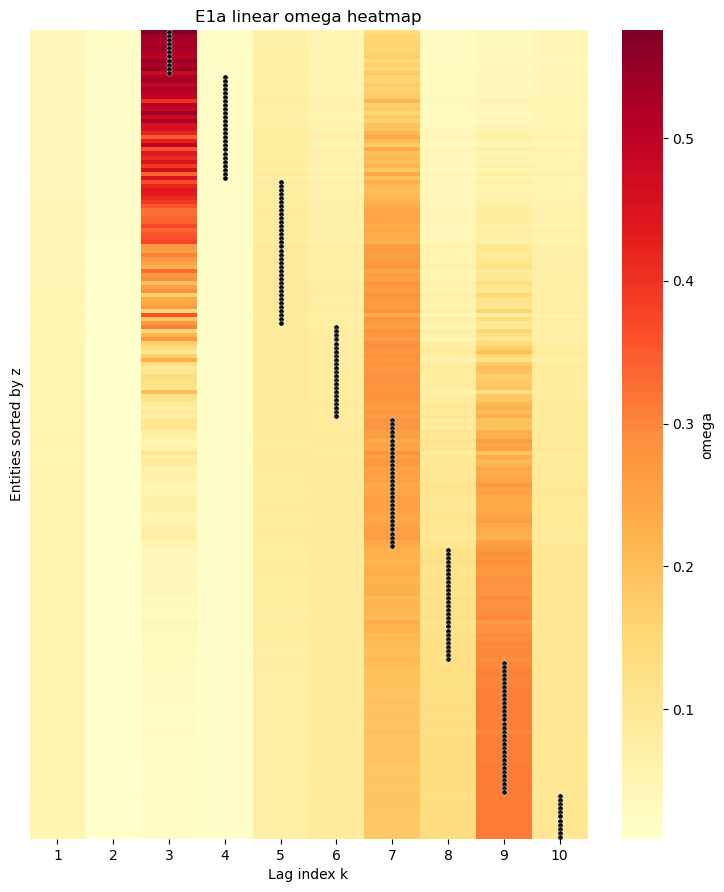

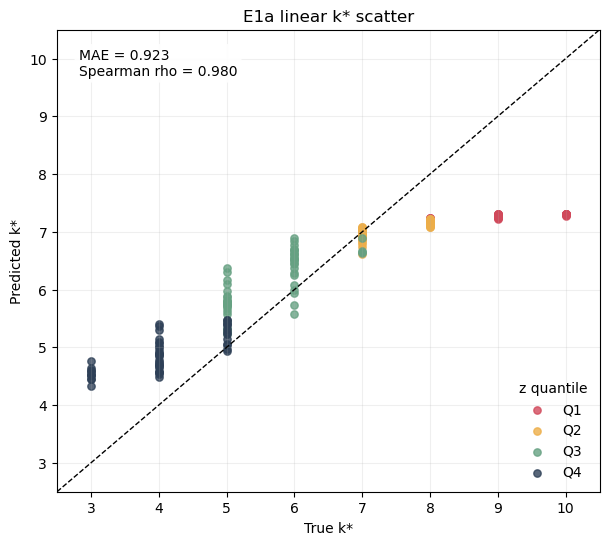

In [20]:
linear_predictions = load_predictions("E1a_linear")
if linear_predictions is None:
    raise FileNotFoundError("Missing E1a_linear/predictions.csv. Please run the experiment cell first.")

display(
    linear_predictions[["entity_id", "z_true", "z_pred", "kstar_true", "kstar_pred", "omega_peak"]].head()
 )

# Keep only omega_1 ... omega_K and exclude omega_peak. / 只保留 omega_1 到 omega_K，排除 omega_peak。
linear_omega_columns = sorted(
    [column for column in linear_predictions.columns if column.startswith("omega_") and column[6:].isdigit()],
    key=lambda name: int(name.split("_")[1]),
)
linear_omega = linear_predictions[linear_omega_columns].to_numpy()

# Re-render the saved outputs inline for notebook inspection. / 在 notebook 中重新渲染保存结果，方便直接查看。
linear_heatmap_ax = plot_omega_heatmap(
    linear_omega,
    linear_predictions["z_true"].to_numpy(),
    linear_predictions["kstar_true"].to_numpy(),
    save_path=None,
)
linear_heatmap_ax.set_title("E1a linear omega heatmap")
plt.show()

linear_scatter_ax = plot_kstar_scatter(
    linear_predictions["kstar_pred"].to_numpy(),
    linear_predictions["kstar_true"].to_numpy(),
    save_path=None,
    z_values=linear_predictions["z_true"].to_numpy(),
)
linear_scatter_ax.set_title("E1a linear k* scatter")
plt.show()

,entity_id,z_true,z_pred,kstar_true,kstar_pred,omega_peak
0,0,0.773956,0.406511,1.0,1.437363,1
1,1,0.438878,-0.030470,3.0,3.436121,1
2,2,0.858598,0.506275,1.0,1.339899,1
3,3,0.697368,0.359451,1.0,1.503734,1
4,4,0.094177,-0.805499,8.0,7.551008,7


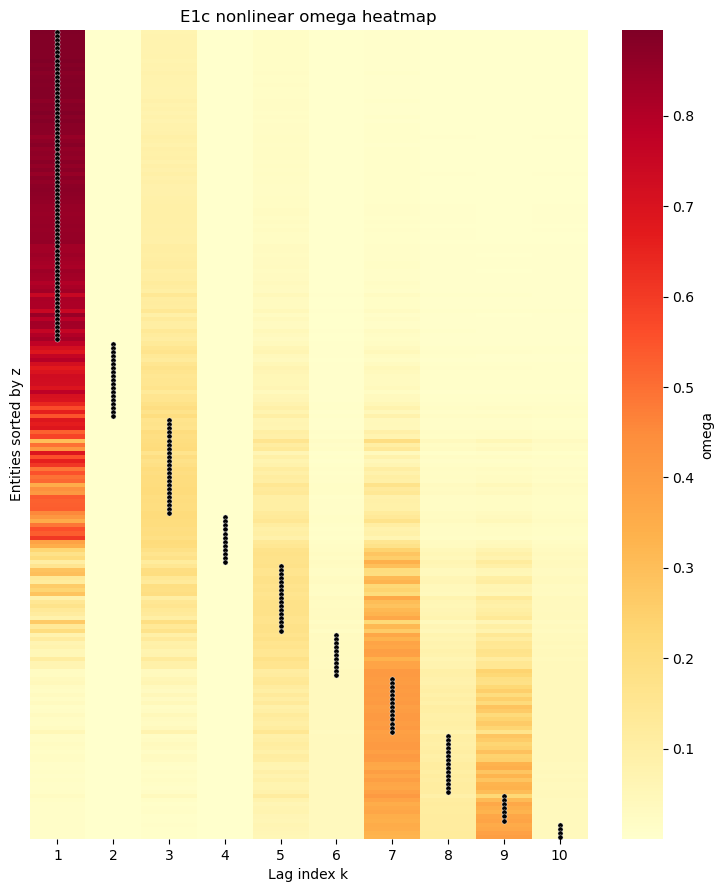

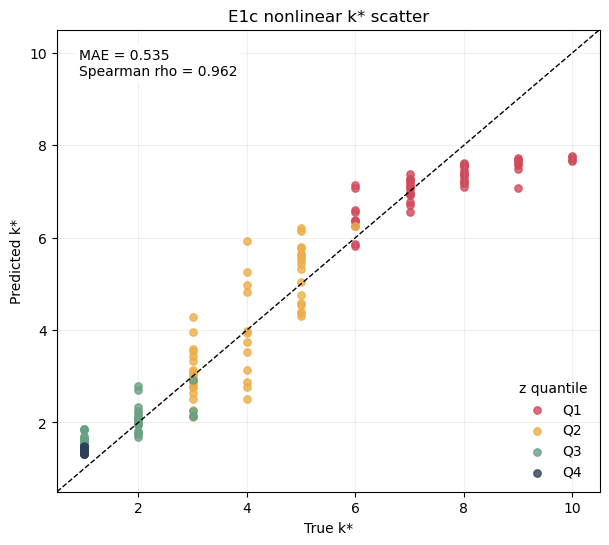

,experiment,scenario,kstar_mae,kstar_spearman_rho,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear,linear,0.922937,0.980482,0.943949,1.914214,0.335
1,E1c_nonlinear,nonlinear,0.534771,0.962223,0.926375,1.170950,0.470


In [21]:
nonlinear_predictions = load_predictions("E1c_nonlinear")

if nonlinear_predictions is None:
    print("Nonlinear experiment was not executed. / 当前未执行非线性实验。")
else:
    display(
        nonlinear_predictions[["entity_id", "z_true", "z_pred", "kstar_true", "kstar_pred", "omega_peak"]].head()
    )

    # Keep only omega_1 ... omega_K and exclude omega_peak. / 只保留 omega_1 到 omega_K，排除 omega_peak。
    nonlinear_omega_columns = sorted(
        [column for column in nonlinear_predictions.columns if column.startswith("omega_") and column[6:].isdigit()],
        key=lambda name: int(name.split("_")[1]),
    )
    nonlinear_omega = nonlinear_predictions[nonlinear_omega_columns].to_numpy()

    nonlinear_heatmap_ax = plot_omega_heatmap(
        nonlinear_omega,
        nonlinear_predictions["z_true"].to_numpy(),
        nonlinear_predictions["kstar_true"].to_numpy(),
        save_path=None,
    )
    nonlinear_heatmap_ax.set_title("E1c nonlinear omega heatmap")
    plt.show()

    nonlinear_scatter_ax = plot_kstar_scatter(
        nonlinear_predictions["kstar_pred"].to_numpy(),
        nonlinear_predictions["kstar_true"].to_numpy(),
        save_path=None,
        z_values=nonlinear_predictions["z_true"].to_numpy(),
    )
    nonlinear_scatter_ax.set_title("E1c nonlinear k* scatter")
    plt.show()

comparison_rows = []
for payload in [linear_summary, nonlinear_summary]:
    if payload is None:
        continue
    comparison_rows.append(
        {
            "experiment": payload["experiment"],
            "scenario": payload["scenario"],
            "kstar_mae": payload["metrics"].get("kstar_mae"),
            "kstar_spearman_rho": payload["metrics"].get("kstar_spearman_rho"),
            "proxy_recon_r2": payload["metrics"].get("proxy_recon_r2"),
            "omega_entropy_mean": payload["metrics"].get("omega_entropy_mean"),
            "omega_peak_accuracy": payload["metrics"].get("omega_peak_accuracy"),
        }
    )

comparison_frame = pd.DataFrame(comparison_rows)
display(comparison_frame)

## Retrospective Diagnostics / 回顾性诊断

This section is no longer trying to explain a current Step 4 failure. Instead, it verifies two retrospective claims:
本节不再用于解释一个“当前仍存在的 Step 4 失败”，而是回顾性验证两个判断：

1. the earlier proxy reconstruction failure was not caused by data impossibility, because z_pred still supports a high-quality linear proxy fit; / 早期 proxy 重构失败不是因为数据不可重构，因为 z_pred 仍支持高质量线性映射；
2. the current post-selection refit closes the gap almost exactly to that linear upper bound. / 当前的评估前重拟合几乎精确补齐了这条线性上限与模型原输出之间的差距。

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from config.cmdl_config import CMDLConfig
from data.synthetic.generate import generate_cmdl_synthetic


# Diagnose whether proxy reconstruction is limited by the data-generator design or by the trained model. / 区分 proxy 重构问题来自数据生成设计还是训练后的模型。
debug_cfg = CMDLConfig.from_domain("synthetic", scenario="linear", seed=42)
debug_panel = generate_cmdl_synthetic(debug_cfg)

proxy_true_columns = [column for column in linear_predictions.columns if column.startswith("proxy_") and column.endswith("_true")]
proxy_true = linear_predictions[proxy_true_columns].to_numpy()
z_pred = linear_predictions[["z_pred"]].to_numpy()
z_true = linear_predictions[["z_true"]].to_numpy()

best_linear_from_z_true = LinearRegression().fit(z_true, proxy_true).predict(z_true)
best_linear_from_z_pred = LinearRegression().fit(z_pred, proxy_true).predict(z_pred)

proxy_debug_table = pd.DataFrame(
    [
        {
            "diagnostic": "best_linear_proxy_r2_from_z_true",
            "value": r2_score(proxy_true, best_linear_from_z_true, multioutput="uniform_average"),
        },
        {
            "diagnostic": "best_linear_proxy_r2_from_z_pred",
            "value": r2_score(proxy_true, best_linear_from_z_pred, multioutput="uniform_average"),
        },
        {
            "diagnostic": "model_proxy_recon_r2",
            "value": extract_metric(e1b_summary, "proxy_recon_r2"),
        },
    ]
)

# Diagnose whether lagged inputs are highly collinear across lag positions. / 检查不同 lag 的输入是否高度共线。
x_values = debug_panel.X_it.squeeze(-1).detach().cpu().numpy()
lag_series = [
    x_values[:, debug_cfg.max_lag - lag : debug_cfg.seq_length - lag].reshape(-1)
    for lag in range(1, debug_cfg.max_lag + 1)
 ]
lag_corr = np.corrcoef(lag_series)
lag_corr_df = pd.DataFrame(
    lag_corr,
    index=[f"lag_{lag}" for lag in range(1, debug_cfg.max_lag + 1)],
    columns=[f"lag_{lag}" for lag in range(1, debug_cfg.max_lag + 1)],
)
mean_abs_offdiag_corr = (np.abs(lag_corr).sum() - np.abs(np.diag(lag_corr)).sum()) / (lag_corr.size - len(lag_corr))

# Summarize the learned peak locations to confirm mode collapse around a few lags. / 汇总学习到的峰值位置，确认是否塌缩到少数 lag。
linear_peak_counts = linear_predictions["omega_peak"].value_counts().sort_index()
nonlinear_peak_counts = nonlinear_predictions["omega_peak"].value_counts().sort_index() if nonlinear_predictions is not None else pd.Series(dtype=int)

peak_debug_table = pd.DataFrame(
    {
        "linear_peak_count": linear_peak_counts,
        "nonlinear_peak_count": nonlinear_peak_counts,
    }
).fillna(0).astype(int)
peak_debug_table.index.name = "omega_peak"

display(proxy_debug_table)
display(pd.DataFrame([{
    "diagnostic": "mean_abs_offdiag_lag_corr",
    "value": mean_abs_offdiag_corr,
}]))
display(lag_corr_df.round(3))
display(peak_debug_table)

if proxy_debug_table.loc[proxy_debug_table["diagnostic"] == "best_linear_proxy_r2_from_z_true", "value"].item() < 0.5:
    print("Proxy reconstruction ceiling is already low with a linear map from z_true, so the generator/head pair is mismatched.")
    print("即使直接用 z_true 做线性重构，proxy R2 上限也偏低，说明当前生成器与线性重构头存在结构不匹配。")

if mean_abs_offdiag_corr > 0.5:
    print("Lagged inputs are strongly correlated across k, so k* is only weakly identifiable from the task loss alone.")
    print("不同 lag 的输入高度相关，因此仅靠任务损失时，k* 的可识别性会偏弱。")

,diagnostic,value
0,best_linear_proxy_r2_from_z_true,0.939191
1,best_linear_proxy_r2_from_z_pred,0.943990
2,model_proxy_recon_r2,0.943949


,diagnostic,value
0,mean_abs_offdiag_lag_corr,0.308545


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
lag_1,1.000,0.660,0.429,0.280,0.201,0.140,0.108,0.088,0.064,0.047
lag_2,0.660,1.000,0.659,0.426,0.276,0.195,0.142,0.110,0.088,0.067
lag_3,0.429,0.659,1.000,0.654,0.416,0.268,0.193,0.143,0.108,0.090
lag_4,0.280,0.426,0.654,1.000,0.650,0.409,0.262,0.195,0.143,0.107
lag_5,0.201,0.276,0.416,0.650,1.000,0.649,0.409,0.266,0.198,0.144
lag_6,0.140,0.195,0.268,0.409,0.649,1.000,0.652,0.415,0.271,0.203
lag_7,0.108,0.142,0.193,0.262,0.409,0.652,1.000,0.652,0.413,0.273
lag_8,0.088,0.110,0.143,0.195,0.266,0.415,0.652,1.000,0.648,0.415
lag_9,0.064,0.088,0.108,0.143,0.198,0.271,0.413,0.648,1.000,0.658
lag_10,0.047,0.067,0.090,0.107,0.144,0.203,0.273,0.415,0.658,1.000


,linear_peak_count,nonlinear_peak_count
omega_peak,,
1,0,133
3,64,0
7,55,60
9,81,7


## Historical Sweep / 历史配置回看

This sweep reruns the historical hyperparameter settings under the current code path to compare k* recovery behavior.
本节在当前代码路径下重跑历史超参配置，用于比较 k* 恢复行为。

Important note: because the proxy head is now refit after best-checkpoint selection, the proxy_recon_r2 values below should be read as the recoverability of proxy information from the learned z representation, not as the training-time convergence quality of the original reconstructor.
注意：由于当前流程会在 best checkpoint 选出后重拟合 proxy head，下表中的 proxy_recon_r2 应理解为“学到的 z 对 proxy 信息的可恢复程度”，而不是“原始训练阶段 reconstructor 的收敛质量”。

In [23]:
from copy import deepcopy

debug_output_root = repo_root / "outputs" / "notebook_step4" / "debug_sweeps"
debug_output_root.mkdir(parents=True, exist_ok=True)

debug_configs = [
    {"name": "baseline_60", "epochs": 60, "patience": 15, "lambda_r": 0.1, "temperature": 1.0, "lag_bias_strength": 1.0},
    {"name": "sharp_gate", "epochs": 60, "patience": 15, "lambda_r": 0.1, "temperature": 0.3, "lag_bias_strength": 0.1},
    {"name": "recon_focus", "epochs": 60, "patience": 15, "lambda_r": 1.0, "temperature": 1.0, "lag_bias_strength": 1.0},
    {"name": "combined", "epochs": 60, "patience": 15, "lambda_r": 1.0, "temperature": 0.3, "lag_bias_strength": 0.1},
]

debug_rows = []
for config in debug_configs:
    debug_args_dict = deepcopy(COMMON_ARGS)
    debug_args_dict.update(
        {
            "scenario": "linear",
            "epochs": config["epochs"],
            "patience": config["patience"],
            "lambda_r": config["lambda_r"],
            "temperature": config["temperature"],
            "lag_bias_strength": config["lag_bias_strength"],
            "log_every": 20,
            "output_dir": str(debug_output_root / config["name"]),
        }
    )
    debug_args = Namespace(**debug_args_dict)
    debug_linear_result = run_e1a(debug_args)
    debug_e1b_summary = run_e1b(debug_args, debug_linear_result)
    debug_predictions = pd.read_csv(Path(debug_args.output_dir) / "E1a_linear" / "predictions.csv")

    debug_rows.append(
        {
            "name": config["name"],
            "epochs": config["epochs"],
            "lambda_r": config["lambda_r"],
            "temperature": config["temperature"],
            "lag_bias_strength": config["lag_bias_strength"],
            "kstar_mae": debug_linear_result.metrics["kstar_mae"],
            "kstar_spearman_rho": debug_linear_result.metrics["kstar_spearman_rho"],
            "omega_peak_accuracy": debug_linear_result.metrics["omega_peak_accuracy"],
            "omega_entropy_mean": debug_linear_result.metrics["omega_entropy_mean"],
            "proxy_recon_r2": debug_e1b_summary["metrics"]["proxy_recon_r2"],
            "z_spearman_rho": debug_e1b_summary["metrics"]["z_spearman_rho"],
            "unique_omega_peaks": int(debug_predictions["omega_peak"].nunique()),
            "min_omega_peak": int(debug_predictions["omega_peak"].min()),
            "max_omega_peak": int(debug_predictions["omega_peak"].max()),
        }
    )

debug_sweep_table = pd.DataFrame(debug_rows).sort_values(["kstar_mae", "proxy_recon_r2"], ascending=[True, False])
display(debug_sweep_table)

[E1a_linear] epoch=001 train_total=0.5471 val_task=0.5098 val_kstar_mae=2.8890 val_proxy_r2=-26.6310
[E1a_linear] epoch=020 train_total=0.2048 val_task=0.1202 val_kstar_mae=2.4114 val_proxy_r2=-30.6086
[E1a_linear] epoch=040 train_total=0.2064 val_task=0.1038 val_kstar_mae=2.1155 val_proxy_r2=-35.1164
[E1a_linear] epoch=060 train_total=0.1842 val_task=0.0966 val_kstar_mae=1.8468 val_proxy_r2=-33.6852
[E1a_linear] epoch=001 train_total=0.5445 val_task=0.5084 val_kstar_mae=3.5124 val_proxy_r2=-26.6314
[E1a_linear] epoch=020 train_total=0.2085 val_task=0.1376 val_kstar_mae=1.9516 val_proxy_r2=-29.8335
[E1a_linear] epoch=040 train_total=0.1855 val_task=0.1196 val_kstar_mae=1.7471 val_proxy_r2=-28.6831
[E1a_linear] epoch=060 train_total=0.1627 val_task=0.0933 val_kstar_mae=1.3651 val_proxy_r2=-29.0678
[E1a_linear] epoch=001 train_total=1.6500 val_task=0.5098 val_kstar_mae=2.8890 val_proxy_r2=-26.6310
[E1a_linear] epoch=020 train_total=1.3962 val_task=0.1197 val_kstar_mae=2.4087 val_proxy_r2

,name,epochs,lambda_r,temperature,lag_bias_strength,kstar_mae,kstar_spearman_rho,omega_peak_accuracy,omega_entropy_mean,proxy_recon_r2,z_spearman_rho,unique_omega_peaks,min_omega_peak,max_omega_peak
3,combined,60,1.0,0.3,0.1,1.038329,0.979836,0.215,0.903054,0.938423,0.988531,2,3,7
1,sharp_gate,60,0.1,0.3,0.1,1.075580,0.979836,0.215,0.883076,0.938465,0.988531,2,3,7
2,recon_focus,60,1.0,1.0,1.0,1.446052,0.979912,0.215,2.008716,0.940275,0.988765,2,3,7
0,baseline_60,60,0.1,1.0,1.0,1.454927,0.979845,0.215,2.010594,0.939846,0.988714,2,3,7


<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>